In [1]:
# Cell 1: Environment Locking & Isolation (Manifesto Rule 4.1)
import sys
from pathlib import Path

expected_env_name = "scotland-ai-split-zones"
actual_path = Path(sys.executable)

assert expected_env_name in str(actual_path), (
    f"Kernel mismatch. Expected environment containing '{expected_env_name}', "
    f"but running in {actual_path}. Run `uv run jupyter lab` from the project root."
)
print(f"Environment verified: {actual_path}")

Environment verified: /home/ndrew/scotland-ai-split-zones/.venv/bin/python3


In [2]:
# Cell 2: Imports and Config Loading
import polars as pl
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

ROOT_DIR = Path.cwd().parent
CONFIG_DIR = ROOT_DIR / "configs"
DATA_INTERMEDIATE = ROOT_DIR / "data" / "intermediate"
FIGURES_DIR = ROOT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load configurations (Manifesto Rule: Configuration, Not Magic Numbers)
with open(CONFIG_DIR / "workload_flexibility_assumptions.yml", "r") as f:
    workload_config = yaml.safe_load(f)

with open(CONFIG_DIR / "absorption_proxies.yml", "r") as f:
    absorption_config = yaml.safe_load(f)

curtailment_factor = absorption_config["curtailment_availability_factor"]["value"]
print(f"Loaded curtailment availability factor: {curtailment_factor}")

Loaded curtailment availability factor: 0.5


In [3]:
# Cell 3: Parquet Handoff (Manifesto Rule 4.2)
# Read validated inputs from Notebook 01 and Notebook 03.

site_register_path = DATA_INTERMEDIATE / "candidate_site_register.parquet"
burden_path = DATA_INTERMEDIATE / "residual_grid_burden.parquet"

if not site_register_path.exists() or not burden_path.exists():
    raise FileNotFoundError("Parquet handoff failed. Please run Notebooks 01 and 03 to completion.")

site_register = pl.read_parquet(site_register_path)
burden_df = pl.read_parquet(burden_path)

print(f"Loaded {len(site_register)} sites and {len(burden_df)} burden scenarios.")

Loaded 7 sites and 336 burden scenarios.


In [4]:
# Cell 4: Renewable Absorption Calculation (FIXED)
# Manifesto Rule: Mechanism Before Model. 
# Formula: Renewable Absorption = min(Schedulable AI Load, Available Curtailed Wind, Site Connection Capacity)
# 
# KEY DISTINCTION: 
# - AI Campus Load = how much power the data centre draws (demand-side)
# - Site Capacity = wind farm capacity (supply-side)
# These are separate quantities. A 500 MW AI campus can be colocated with a 539 MW wind farm.

# Define the AI campus load explicitly (not using site capacity as proxy)
AI_CAMPUS_LOAD_MW = 500.0  # Representative hyperscale campus

# Recalculate duration compatibility factor (from Notebook 02 logic)
def calc_duration_compatibility(event_duration_h, notice_period_h):
    return min(1.0, event_duration_h / notice_period_h)

# Join site register (to get capacity_mw) with the burden scenarios
absorption_df = burden_df.join(
    site_register.select(["site_name", "capacity_mw"]), 
    on="site_name", 
    how="left"
).with_columns(
    # Recalculate duration compatibility factor
    (pl.min_horizontal(pl.col("event_duration_h"), pl.col("notice_period_h")) / pl.col("notice_period_h")).alias("duration_compatibility_factor")
).with_columns(
    # Calculate the schedulable AI load (the demand-side ceiling)
    (pl.lit(AI_CAMPUS_LOAD_MW) * pl.col("schedulable_fraction") * pl.col("duration_compatibility_factor")).alias("schedulable_ai_load_mw"),
    
    # Calculate the MVP proxy for available curtailed energy (the supply-side ceiling)
    (pl.col("capacity_mw") * pl.lit(curtailment_factor)).alias("available_curtailed_mw_proxy"),
    
    # Calculate the actual absorption as the minimum of the three constraints
    pl.min_horizontal(
        pl.lit(AI_CAMPUS_LOAD_MW) * pl.col("schedulable_fraction") * pl.col("duration_compatibility_factor"),  # Schedulable AI load
        (pl.col("capacity_mw") * pl.lit(curtailment_factor)),  # Available curtailed wind
        pl.col("capacity_mw")  # Site connection capacity
    ).alias("renewable_absorption_mw")
).select([
    "site_name",
    "constraint_direction",
    "capacity_mw",
    "notice_period_h",
    "schedulable_fraction",
    "event_duration_h",
    "duration_compatibility_factor",
    "schedulable_ai_load_mw",
    "available_curtailed_mw_proxy",
    "renewable_absorption_mw"
])

# Assertions Protect Physics
assert (absorption_df["renewable_absorption_mw"] >= 0).all(), "Physical violation: Absorption cannot be negative."
assert (absorption_df["renewable_absorption_mw"] <= absorption_df["schedulable_ai_load_mw"]).all(), "Physical violation: Absorption cannot exceed schedulable AI load."
assert (absorption_df["renewable_absorption_mw"] <= absorption_df["available_curtailed_mw_proxy"]).all(), "Physical violation: Absorption cannot exceed available curtailed wind."

print("Renewable absorption calculated for all scenarios.")
print(absorption_df.head(3))
# Verify the 50% schedulable scenario specifically
print("\n--- VERIFICATION: 50% Schedulable Scenario ---")
verification = absorption_df.filter(
    (pl.col("schedulable_fraction") == 0.5) &
    (pl.col("notice_period_h") == 4) &
    (pl.col("event_duration_h") == 4) &
    (pl.col("site_name") == "Whitelee Wind Farm")
).select([
    "site_name",
    "schedulable_fraction",
    "duration_compatibility_factor",
    "schedulable_ai_load_mw",
    "available_curtailed_mw_proxy",
    "renewable_absorption_mw"
])
print(verification)

Renewable absorption calculated for all scenarios.
shape: (3, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ site_name ┆ constrain ┆ capacity_ ┆ notice_pe ┆ … ┆ duration_ ┆ schedulab ┆ available ┆ renewabl │
│ ---       ┆ t_directi ┆ mw        ┆ riod_h    ┆   ┆ compatibi ┆ le_ai_loa ┆ _curtaile ┆ e_absorp │
│ str       ┆ on        ┆ ---       ┆ ---       ┆   ┆ lity_fact ┆ d_mw      ┆ d_mw_prox ┆ tion_mw  │
│           ┆ ---       ┆ f64       ┆ i64       ┆   ┆ or        ┆ ---       ┆ y         ┆ ---      │
│           ┆ str       ┆           ┆           ┆   ┆ ---       ┆ f64       ┆ ---       ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆           ┆ f64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ Whitelee  ┆ export    ┆ 539.0     ┆ 4         ┆ … ┆ 0.5       ┆ 0.0       ┆ 269.5     ┆ 0.0      │
│ Wind Farm ┆           ┆

In [5]:
# Cell 5: Parquet Handoff (Save for Notebook 05)
output_path = DATA_INTERMEDIATE / "renewable_absorption.parquet"
absorption_df.write_parquet(output_path)
print(f"Saved renewable absorption matrix to {output_path}")

Saved renewable absorption matrix to /home/ndrew/scotland-ai-split-zones/data/intermediate/renewable_absorption.parquet


Saved figure to /home/ndrew/scotland-ai-split-zones/figures/renewable_absorption_mismatch_comparison.png


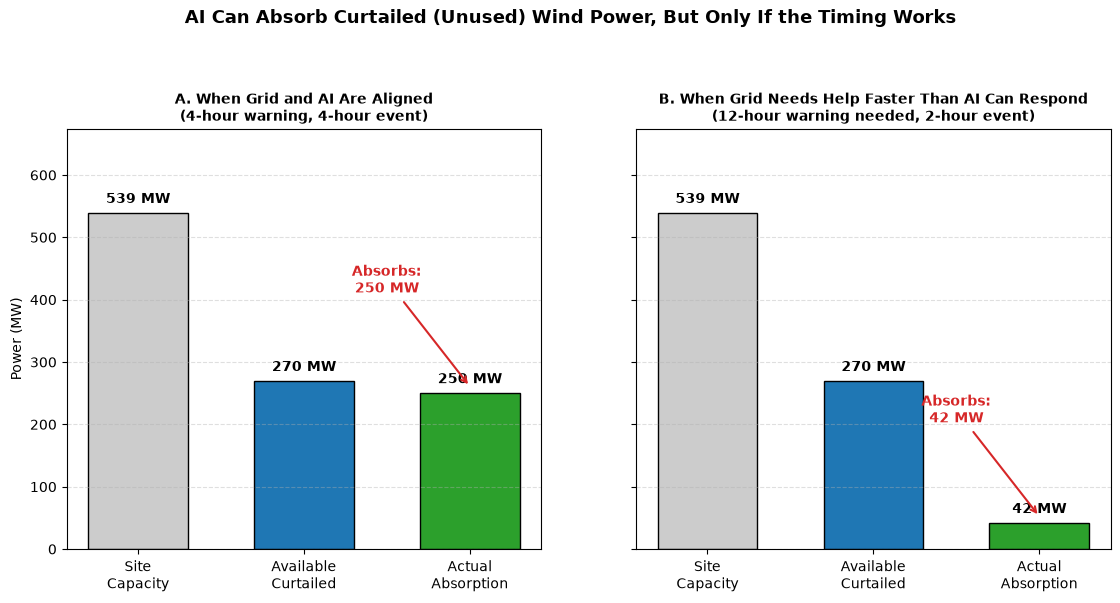


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CHART EXPLANATION:

Chart A shows the best-case scenario: when the grid's constraint event 
lasts 4 hours and the AI data centre receives 4 hours of advance warning, 
the AI can fully flex its schedulable workload to absorb 250 MW of curtailed 
wind power (the maximum allowed by the 50% schedulability ceiling).

Chart B shows the realistic scenario: when the grid experiences a sharp 
2-hour constraint but the AI system requires 12 hours to safely pause and 
restart its training jobs, the absorption collapses to just 42 MW.

KEY INSIGHT: AI flexibility is not a fixed number. It depends on whether 
the grid's timing matches the data centre's IT operations. A "50% flexibility" 
claim can deliver anywhere from 250 MW to 42 MW depending on the event duration. 
This represents a loss of 208 MW of *potentially flexible* load due to 
timescale mismatch. The remaining 250 MW of the 500 MW campus was never 
flexible to begin with (infle

In [6]:
# Cell 6: Tufte-Compliant Visualization (The Bottleneck: Best Case vs. Realistic Mismatch)
# Manifesto Rule 9.3: Show causation, comparison, and context.

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Scenario A: Perfect Match
scenario_a = absorption_df.filter(
    (pl.col("schedulable_fraction") == 0.5) &
    (pl.col("notice_period_h") == 4) &
    (pl.col("event_duration_h") == 4) &
    (pl.col("site_name") == "Whitelee Wind Farm")
)

# Scenario B: Timescale Mismatch
scenario_b = absorption_df.filter(
    (pl.col("schedulable_fraction") == 0.5) &
    (pl.col("notice_period_h") == 12) &
    (pl.col("event_duration_h") == 2) &
    (pl.col("site_name") == "Whitelee Wind Farm")
)

x_labels = ["Site\nCapacity", "Available\nCurtailed", "Actual\nAbsorption"]
x = range(len(x_labels))
width = 0.6

def plot_bottleneck(ax, scenario, title, subtitle):
    capacity = scenario["capacity_mw"].to_list()[0]
    curtailed = scenario["available_curtailed_mw_proxy"].to_list()[0]
    absorbed = scenario["renewable_absorption_mw"].to_list()[0]
    
    bars = ax.bar(x, [capacity, curtailed, absorbed], width, color=["#cccccc", "#1f77b4", "#2ca02c"], edgecolor="black")
    
    ax.set_title(f"{title}\n{subtitle}", fontweight="bold", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0, capacity * 1.25)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + (capacity * 0.02), f"{yval:.0f} MW", ha="center", va="bottom", fontsize=10, fontweight="bold")
    
    annotation_text = f"Absorbs:\n{absorbed:.0f} MW"
    ax.annotate(
        annotation_text,
        xy=(2, absorbed + (capacity * 0.02)),
        xytext=(1.5, absorbed + (capacity * 0.3)),
        fontsize=10, fontweight="bold", color="#d62728", ha="center",
        arrowprops=dict(arrowstyle="->", color="#d62728", lw=1.5)
    )

# Chart A: Best Case
plot_bottleneck(
    axes[0], scenario_a, 
    "A. When Grid and AI Are Aligned",
    "(4-hour warning, 4-hour event)"
)
axes[0].set_ylabel("Power (MW)")

# Chart B: Realistic Mismatch
plot_bottleneck(
    axes[1], scenario_b, 
    "B. When Grid Needs Help Faster Than AI Can Respond",
    "(12-hour warning needed, 2-hour event)"
)

# FIXED: British English safe title
plt.suptitle(
    "AI Can Absorb Curtailed (Unused) Wind Power, But Only If the Timing Works", 
    fontsize=13, fontweight="bold", y=1.05
)

fig.subplots_adjust(top=0.85, bottom=0.15, left=0.08, right=0.95)

fig_path = FIGURES_DIR / "renewable_absorption_mismatch_comparison.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to {fig_path}")
plt.show()

# Plain-English explanation
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CHART EXPLANATION:

Chart A shows the best-case scenario: when the grid's constraint event 
lasts 4 hours and the AI data centre receives 4 hours of advance warning, 
the AI can fully flex its schedulable workload to absorb 250 MW of curtailed 
wind power (the maximum allowed by the 50% schedulability ceiling).

Chart B shows the realistic scenario: when the grid experiences a sharp 
2-hour constraint but the AI system requires 12 hours to safely pause and 
restart its training jobs, the absorption collapses to just 42 MW.

KEY INSIGHT: AI flexibility is not a fixed number. It depends on whether 
the grid's timing matches the data centre's IT operations. A "50% flexibility" 
claim can deliver anywhere from 250 MW to 42 MW depending on the event duration. 
This represents a loss of 208 MW of *potentially flexible* load due to 
timescale mismatch. The remaining 250 MW of the 500 MW campus was never 
flexible to begin with (inflexible baseline).

POLICY IMPLICATION: Grid operators cannot rely on AI flexibility for short, 
sharp constraint events unless data centres upgrade their systems to respond 
faster. The timescale mismatch specifically destroys the *claimed* flexibility, 
not the entire load.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")